# Deep Gaussian Process (DGP) dari Nol (From Scratch)

Welcome! Notebook ini dirancang sebagai panduan langkah-demi-langkah (*walkthrough*) untuk memahami dan mengimplementasikan **Deep Gaussian Process (DGP)** dari dasar (*from scratch*).

---

## 🎯 Tujuan Pembelajaran
1. **Memahami Keterbatasan Single-Layer GP**: Mengapa Gaussian Process standar kesulitan menangani data *non-stationary* (misalnya fungsi dengan frekuensi berubah cepat atau lompatan mendadak).
2. **Konsep Komposisi Layer pada DGP**: Bagaimana fungsi laten dihubungkan secara hierarkis ($y = f^{(L)}(f^{(L-1)}(\dots f^{(1)}(x)))$) untuk melakukan *input space warping*.
3. **Variational Inference & Inducing Points (DSVI)**: Solusi matematika (Salimbeni & Deisenroth, 2017) untuk mengestimasi *posterior intractable* pada DGP menggunakan titik induksi (*inducing points*) dan *reparameterization trick*.
4. **Implementasi From-Scratch dalam PyTorch**: Membangun Kernel RBF, Variational GP Layer, dan Deep GP Model menggunakan operasi tensor dasar PyTorch tanpa bantuan library GP tingkat tinggi (seperti GPyTorch atau GPflow).
5. **Visualisasi Space Warping**: Mengamati bagaimana layer tersembunyi (*hidden layer*) mengubah representasi ruang input sehingga fungsi non-stasioner menjadi mudah dipelajari.

## 1. Setup Environment & Library

Kita hanya menggunakan library dasar Python:
- `numpy`: Manipulasi data sintetis dan numerik dasar.
- `matplotlib.pyplot`: Visualisasi fungsi, uncertainty boundary, dan representasi laten.
- `torch` & `torch.nn`: Operasi aljabar linier tensor dan *automatic differentiation* (autograd) untuk mengoptimalkan parameter ELBO.

> **Catatan**: Kita **tidak** menggunakan `gpytorch`, `gpflow`, atau library GP ber-level tinggi lainnya. Semua logika kernel, matriks kovariansi, inferensi variasional, dan ELBO dibuat murni dari persamaan matematikanya.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time

# Set random seed untuk hasil yang reproducible
torch.manual_seed(42)
np.random.seed(42)

# Set style plot Matplotlib agar tampak profesional
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100

print(f"PyTorch Version: {torch.__version__}")
print("Environment siap untuk eksplorasi Deep Gaussian Process!")

PyTorch Version: 2.12.0+cpu
Environment siap untuk eksplorasi Deep Gaussian Process!


## 2. Motivasi: Keterbatasan Single-Layer Gaussian Process (Standard GP)

### Mengapa Single GP Kesulitan pada Data Non-Stationary?
Suatu proses Gauss (GP) standar dengan Kernel Radial Basis Function (RBF / Squared Exponential) memiliki asumsi **stasioneritas** (*stationarity*):
$$k_{RBF}(x, x') = \sigma_f^2 \exp\left( -\frac{\|x - x'\|^2}{2\ell^2} \right)$$

Di sini, hyperparameter *lengthscale* $\ell$ bersifat global (konstan di seluruh ruang input $x$).
- Jika $\ell$ terlalu besar, GP akan **over-smooth** pada area yang berubah cepat (frekuensi tinggi / lompatan).
- Jika $\ell$ terlalu kecil, GP akan **over-fit** pada area yang halus dan menghasilkan ketidakpastian (*uncertainty*) yang tidak realistis pada area yang jarang data.

Mari kita buat dataset sintetis yang bersifat *non-stationary* (gabungan sinyal frekuensi rendah dan frekuensi tinggi).

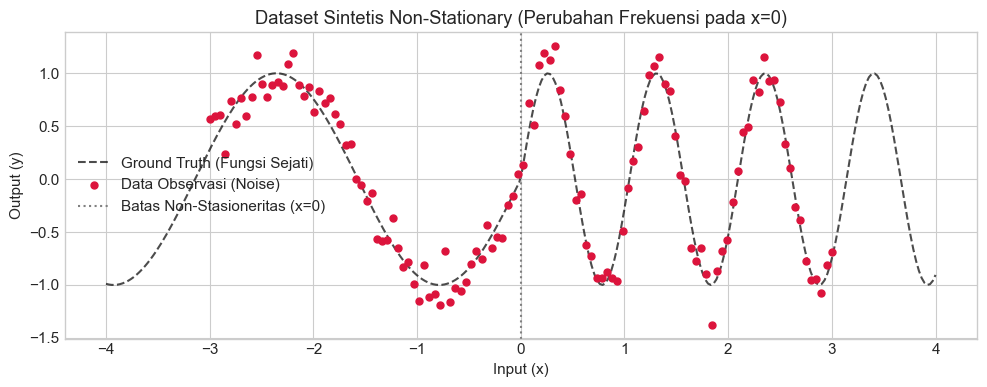

In [2]:
# Membuat Dataset Sintetis Non-Stationary
# x < 0: Frekuensi rendah sin(2x)
# x >= 0: Frekuensi tinggi sin(6x)
N_train = 120
X_train = torch.linspace(-3, 3, N_train).unsqueeze(1)

# Fungsi sejati (ground truth) tanpa noise
y_true = torch.where(X_train < 0, torch.sin(2 * X_train), torch.sin(6 * X_train))

# Menambahkan Gaussian noise N(0, 0.15^2)
noise_std = 0.15
Y_train = y_true + noise_std * torch.randn_like(X_train)

# Test grid untuk evaluasi dan plot prediksi
X_test = torch.linspace(-4, 4, 300).unsqueeze(1)
Y_test_true = torch.where(X_test < 0, torch.sin(2 * X_test), torch.sin(6 * X_test))

# Visualisasi Data Sintetis
plt.figure(figsize=(10, 4))
plt.plot(X_test.numpy(), Y_test_true.numpy(), 'k--', label='Ground Truth (Fungsi Sejati)', alpha=0.7)
plt.scatter(X_train.numpy(), Y_train.numpy(), c='crimson', s=25, label='Data Observasi (Noise)', zorder=3)
plt.axvline(0, color='gray', linestyle=':', label='Batas Non-Stasioneritas (x=0)')
plt.title("Dataset Sintetis Non-Stationary (Perubahan Frekuensi pada x=0)")
plt.xlabel("Input (x)")
plt.ylabel("Output (y)")
plt.legend()
plt.tight_layout()
plt.show()

### Baseline: Single-Layer Variational Gaussian Process (VGP)

Sebelum masuk ke Deep GP, mari kita buat **Single-Layer Variational GP** terlebih dahulu.
Pada Variational GP dengan Inducing Points $Z$:
1. Matriks Kovariansi Kernel $K_{ZZ} = k(Z, Z) + \sigma_{jitter}^2 I$
2. Matriks Kovariansi Input-Inducing $K_{XZ} = k(X, Z)$
3. Matriks Proyeksi $A = K_{XZ} K_{ZZ}^{-1}$
4. Distribusi Kondisional $q(f \mid X)$:
   $$\mu(X) = A m$$
   $$\text{Var}(f(X)) = \text{diag}(K_{XX}) - \text{diag}(A K_{ZX}) + \text{diag}(A S A^T)$$

Mari kita latih Single-Layer VGP ini pada data non-stasioner di atas.

Melatih Single-Layer VGP...


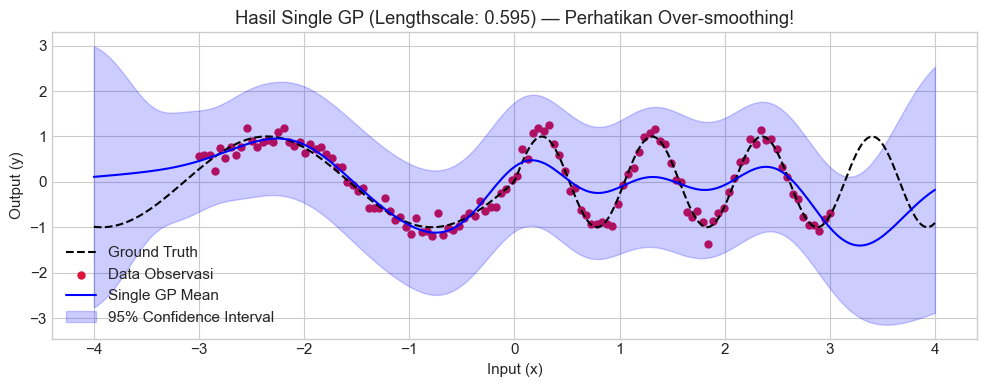

In [3]:
class SingleLayerVGP(nn.Module):
    def __init__(self, input_dim=1, output_dim=1, num_inducing=16, X_init=None):
        super().__init__()
        self.num_inducing = num_inducing
        
        # Hyperparameter Kernel RBF
        self.raw_lengthscale = nn.Parameter(torch.zeros(1, input_dim))
        self.raw_outputscale = nn.Parameter(torch.zeros(1))
        
        # Inducing points Z
        if X_init is not None:
            min_x, max_x = X_init.min(), X_init.max()
            z_init = torch.linspace(min_x, max_x, num_inducing).unsqueeze(1)
        else:
            z_init = torch.linspace(-3.0, 3.0, num_inducing).unsqueeze(1)
        self.Z = nn.Parameter(z_init)
        
        # Parameter Variasional q(U) = N(m, S)
        self.m = nn.Parameter(torch.zeros(num_inducing, output_dim))
        init_L = torch.eye(num_inducing).unsqueeze(0) * 0.1
        self.raw_L_S = nn.Parameter(init_L)
        
        # Observational Noise Variance \sigma_n^2
        self.raw_noise = nn.Parameter(torch.tensor([-2.0]))
        self.jitter = 1e-4

    @property
    def lengthscale(self):
        return torch.exp(self.raw_lengthscale) + 1e-4

    @property
    def outputscale(self):
        return torch.exp(self.raw_outputscale) + 1e-4

    @property
    def noise(self):
        return torch.exp(self.raw_noise) + 1e-4

    def kernel(self, x1, x2):
        x1_s = x1 / self.lengthscale
        x2_s = x2 / self.lengthscale
        dist_sq = torch.cdist(x1_s, x2_s, p=2.0)**2
        return self.outputscale * torch.exp(-0.5 * dist_sq)

    def forward(self, X):
        K_ZZ = self.kernel(self.Z, self.Z) + self.jitter * torch.eye(self.num_inducing)
        K_XZ = self.kernel(X, self.Z)
        
        L_Z = torch.linalg.cholesky(K_ZZ)
        Y = torch.linalg.solve_triangular(L_Z, K_XZ.T, upper=False)
        A = torch.linalg.solve_triangular(L_Z.T, Y, upper=True).T
        
        mu = A @ self.m
        var_prior = self.outputscale - torch.sum(A * K_XZ, dim=1, keepdim=True)
        
        L = torch.tril(self.raw_L_S[0])
        diag_idx = torch.arange(self.num_inducing)
        L[diag_idx, diag_idx] = torch.nn.functional.softplus(L[diag_idx, diag_idx]) + 1e-5
        
        A_L = A @ L
        var_var = torch.sum(A_L**2, dim=1, keepdim=True)
        
        var = torch.clamp(var_prior + var_var, min=1e-5)
        return mu, var

    def kl_divergence(self):
        M = self.num_inducing
        K_ZZ = self.kernel(self.Z, self.Z) + self.jitter * torch.eye(M)
        L_Z = torch.linalg.cholesky(K_ZZ)
        
        L_S = torch.tril(self.raw_L_S[0])
        diag_idx = torch.arange(M)
        L_S[diag_idx, diag_idx] = torch.nn.functional.softplus(L_S[diag_idx, diag_idx]) + 1e-5
        
        logdet_K = 2.0 * torch.sum(torch.log(torch.diagonal(L_Z)))
        logdet_S = 2.0 * torch.sum(torch.log(torch.diagonal(L_S)))
        
        v = torch.linalg.solve_triangular(L_Z, self.m, upper=False)
        quad_term = torch.sum(v**2)
        
        W = torch.linalg.solve_triangular(L_Z, L_S, upper=False)
        trace_term = torch.sum(W**2)
        
        kl = 0.5 * (trace_term + quad_term - M + logdet_K - logdet_S)
        return kl

    def elbo(self, X, Y):
        mu, var = self.forward(X)
        noise = self.noise
        total_var = var + noise
        log_lik = -0.5 * torch.log(2 * np.pi * total_var) - 0.5 * (Y - mu)**2 / total_var
        return torch.sum(log_lik) - self.kl_divergence()

# Inisialisasi & Latih Single VGP
single_gp = SingleLayerVGP(num_inducing=16, X_init=X_train)
opt_single = torch.optim.Adam(single_gp.parameters(), lr=0.01)

print("Melatih Single-Layer VGP...")
for epoch in range(1, 401):
    opt_single.zero_grad()
    loss = -single_gp.elbo(X_train, Y_train)
    loss.backward()
    opt_single.step()

# Evaluasi Single VGP
with torch.no_grad():
    mu_sgp, var_sgp = single_gp(X_test)
    std_sgp = torch.sqrt(var_sgp + single_gp.noise).squeeze().numpy()
    mu_sgp = mu_sgp.squeeze().numpy()

# Visualisasi Prediksi Single VGP
plt.figure(figsize=(10, 4))
plt.plot(X_test.numpy(), Y_test_true.numpy(), 'k--', label='Ground Truth')
plt.scatter(X_train.numpy(), Y_train.numpy(), c='crimson', s=25, label='Data Observasi')
plt.plot(X_test.numpy(), mu_sgp, 'b-', label='Single GP Mean')
plt.fill_between(X_test.squeeze().numpy(), mu_sgp - 2*std_sgp, mu_sgp + 2*std_sgp, color='blue', alpha=0.2, label='95% Confidence Interval')
plt.title(f"Hasil Single GP (Lengthscale: {single_gp.lengthscale.item():.3f}) — Perhatikan Over-smoothing!")
plt.xlabel("Input (x)")
plt.ylabel("Output (y)")
plt.legend()
plt.tight_layout()
plt.show()

### ⚠️ Analisis Hasil Single GP:
Seperti yang terlihat pada grafik di atas:
- **Di wilayah $x < 0$ (frekuensi rendah)**: Single GP mencoba mencocokkan pola gelombang lebar.
- **Di wilayah $x \ge 0$ (frekuensi tinggi)**: Single GP gagal menangkap osilasi cepat karena *lengthscale* $\ell$ bernilai konstan tunggal!
- Akibatnya, GP terpaksa mengambil jalan tengah (*trade-off*): menghasilkan grafik yang **terlalu halus (*over-smoothed*)** di daerah frekuensi tinggi dan **melebar ketidakpastiannya**.

Sekarang, mari kita selidiki bagaimana **Deep Gaussian Process (DGP)** menyelesaikan masalah ini secara elegan!

## 3. Teori & Formulasi Matematika Deep Gaussian Process (DGP)

### 3.1 Komposisi Layer GP (Functional Composition)
Suatu Deep GP dengan $L$ layer didefinisikan sebagai komposisi hirarkis dari $L$ proses Gauss:
$$H^{(1)} = f^{(1)}(X)$$
$$H^{(2)} = f^{(2)}(H^{(1)})$$
$$\dots$$
$$Y = f^{(L)}(H^{(L-1)}) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma_n^2 I)$$

Di mana setiap layer $l$ memiliki fungsi prior $f^{(l)} \sim \mathcal{GP}(0, k^{(l)}(\cdot, \cdot)).$

### 3.2 Masalah Intractability (Marginal Likelihood Murni)
Marginal Likelihood dari data observasi $Y$ mensyaratkan pengintegralan (*marginalization*) terhadap seluruh variabel laten di layer tersembunyi $H^{(1)}, \dots, H^{(L-1)}$:
$$p(Y \mid X) = \int \dots \int p(Y \mid H^{(L-1)}) p(H^{(L-1)} \mid H^{(L-2)}) \dots p(H^{(1)} \mid X) \, dH^{(1)} \dots dH^{(L-1)}$$

Karena variabel laten $H^{(l)}$ masuk ke dalam fungsi kovariansi kernel yang non-linear $k^{(l+1)}(H^{(l)}, H^{(l)})$, integral ini **tidak memiliki solusi analitis** (*analytically intractable*).

---

### 3.3 Solusi: Doubly Stochastic Variational Inference (DSVI)
Salimbeni & Deisenroth (2017) mengajukan skema inferensi variasional yang efisien:

1. **Inducing Points**: Untuk setiap layer $l$, tentukan $M$ titik induksi $Z^{(l)} \in \mathbb{R}^{M \times D_l}$ dan variabel induksi $U^{(l)} = f^{(l)}(Z^{(l)})$.
2. **Distribusi Variasional**: Diasumsikan terpisah (*factorized*) antar layer:
   $$q(U^{(1)}, \dots, U^{(L)}) = \prod_{l=1}^L \mathcal{N}(U^{(l)} \mid m^{(l)}, S^{(l)})$$
3. **Distribusional Kondisional $q(f^{(l)} \mid H^{(l-1)})$**:
   $$q(f^{(l)} \mid H^{(l-1)}) = \mathcal{N}\left( f^{(l)} \mid \mu^{(l)}(H^{(l-1)}), \Sigma^{(l)}(H^{(l-1)}) \right)$$
   di mana:
   $$\mu^{(l)}(H^{(l-1)}) = K_{H Z} K_{Z Z}^{-1} m^{(l)}$$
   $$\Sigma^{(l)}(H^{(l-1)}) = K_{H H} - K_{H Z} K_{Z Z}^{-1} (K_{Z Z} - S^{(l)}) K_{Z Z}^{-1} K_{Z H}$$

4. **Reparameterization Trick Antar Layer**:
   Untuk melewatkan informasi dari layer $l-1$ ke layer $l$, kita melakukan *sampling* sampel Monte Carlo $h_s^{(l)}$ menggunakan teknik reparameterisasi:
   $$h_s^{(l)} = \mu^{(l)}(h_s^{(l-1)}) + \epsilon_s \odot \sqrt{\Sigma^{(l)}(h_s^{(l-1)})}, \quad \epsilon_s \sim \mathcal{N}(0, I)$$

5. **Evidence Lower Bound (ELBO)**:
   Fungsi objektif yang kita maksimalkan (atau kurangi negatifnya) adalah ELBO:
   $$\mathcal{L}_{ELBO} = \sum_{i=1}^N \mathbb{E}_{q(f_i^{(L)})} \left[ \log p(y_i \mid f_i^{(L)}) \right] - \sum_{l=1}^L \text{KL}\left( q(U^{(l)}) \parallel p(U^{(l)}) \right)$$

Di mana suku pertama diestimasi menggunakan sampel Monte Carlo (*Doubly Stochastic*), dan suku kedua (KL-Divergence) dihitung secara analitis untuk setiap layer.

## 4. Implementasi Komponen Deep GP dari Nol (PyTorch Tensors)

Mari kita buat 3 modul PyTorch utama dari nol:
1. `RBFKernel`: Menghitung covariance matrix $K(X_1, X_2)$ berukuran $(N, M)$ atau batched $(S, N, M)$ untuk Monte Carlo samples.
2. `VariationalGPLayer`: Mengelola inducing points $Z$, mean $m$, Cholesky factor $L_S$, menghitung kondisional $\mu, \Sigma$, serta KL-Divergence.
3. `DeepGP`: Menggabungkan beberapa layer `VariationalGPLayer`, menjalankan MC sampling bertingkat dengan reparameterization trick, dan mengkalkulasi total ELBO loss.

In [4]:
class RBFKernel(nn.Module):
    """
    Radial Basis Function (RBF) / Squared Exponential Kernel
    K(x1, x2) = \sigma_f^2 * exp(-0.5 * ||x1 - x2||^2 / \ell^2)
    """
    def __init__(self, input_dim):
        super().__init__()
        # Parameterisasi dalam log-space agar selalu positif setelah exp()
        self.raw_lengthscale = nn.Parameter(torch.zeros(1, input_dim))
        self.raw_outputscale = nn.Parameter(torch.zeros(1))
        
    @property
    def lengthscale(self):
        return torch.exp(self.raw_lengthscale) + 1e-4
    
    @property
    def outputscale(self):
        return torch.exp(self.raw_outputscale) + 1e-4

    def forward(self, x1, x2):
        # x1: (N, D) atau (S, N, D), x2: (M, D)
        x1_scaled = x1 / self.lengthscale
        x2_scaled = x2 / self.lengthscale
        
        if x1.dim() == 2 and x2.dim() == 2:
            dist_sq = torch.cdist(x1_scaled, x2_scaled, p=2.0)**2
        elif x1.dim() == 3 and x2.dim() == 2:
            # Broadcast terhadap sampel Monte Carlo S
            S, N, D = x1.shape
            M, _ = x2.shape
            x2_exp = x2_scaled.unsqueeze(0).expand(S, M, D)
            dist_sq = torch.cdist(x1_scaled, x2_exp, p=2.0)**2
            
        return self.outputscale * torch.exp(-0.5 * dist_sq)

print("Modul RBFKernel berhasil didefinisikan!")

Modul RBFKernel berhasil didefinisikan!


In [5]:
class VariationalGPLayer(nn.Module):
    """
    Satu Layer Variational GP pada Deep GP Architecture
    """
    def __init__(self, input_dim, output_dim, num_inducing=16, inducing_init=None):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.num_inducing = num_inducing
        
        # Kernel RBF khusus layer ini
        self.kernel = RBFKernel(input_dim)
        
        # Inducing points Z: (num_inducing, input_dim)
        if inducing_init is not None:
            self.Z = nn.Parameter(inducing_init.clone())
        else:
            self.Z = nn.Parameter(torch.linspace(-2.0, 2.0, num_inducing).unsqueeze(1).repeat(1, input_dim))
            
        # Parameter Variasional q(U) = N(m, S)
        # m: (num_inducing, output_dim)
        self.m = nn.Parameter(torch.zeros(num_inducing, output_dim))
        
        # Lower Cholesky Matrix L_S di mana S = L_S @ L_S^T
        # Initialized sebagai matriks identitas berukuran kecil
        init_L = torch.eye(num_inducing).unsqueeze(0).repeat(output_dim, 1, 1) * 0.1
        self.raw_L_S = nn.Parameter(init_L)
        
        self.jitter = 1e-4

    def get_L_S(self):
        """Memastikan L_S berupa lower triangular dengan diagonal positif"""
        L = torch.tril(self.raw_L_S)
        diag_idx = torch.arange(self.num_inducing)
        # Softplus pada diagonal untuk kepastian positif
        L[:, diag_idx, diag_idx] = torch.nn.functional.softplus(L[:, diag_idx, diag_idx]) + 1e-5
        return L

    def forward(self, H):
        """
        Input H: (N, input_dim) atau (S, N, input_dim)
        Output: mean mu dan variance var berukuran (S, N, output_dim)
        """
        is_batched = (H.dim() == 3)
        if not is_batched:
            H = H.unsqueeze(0) # (1, N, D)
            
        S, N, D = H.shape
        M = self.num_inducing
        
        # 1. Matriks Kovariansi K_ZZ dan Cholesky-nya (HANYA dihitung 1x per layer per forward call)
        K_ZZ = self.kernel(self.Z, self.Z) + self.jitter * torch.eye(M) # (M, M)
        L_Z = torch.linalg.cholesky(K_ZZ) # (M, M)
        
        # 2. Matriks Kovariansi K_HZ: (S, N, M)
        K_HZ = self.kernel(H, self.Z)
        
        # 3. Matriks Proyeksi A = K_HZ @ K_ZZ^-1
        K_HZ_flat = K_HZ.reshape(S * N, M)
        Y = torch.linalg.solve_triangular(L_Z, K_HZ_flat.T, upper=False) # (M, S*N)
        A_flat = torch.linalg.solve_triangular(L_Z.T, Y, upper=True).T # (S*N, M)
        A = A_flat.reshape(S, N, M) # (S, N, M)
        
        # 4. Ekspektasi Mean: \mu = A @ m => (S, N, output_dim)
        mu = A @ self.m # (S, N, M) @ (M, D_out) -> (S, N, D_out)
        
        # 5. Reduksi Varian Prior: diag(K_HH) - diag(A @ K_ZH)
        var_prior = self.kernel.outputscale - torch.sum(A * K_HZ, dim=-1, keepdim=True) # (S, N, 1)
        
        # 6. Penambahan Varian Variasional: rowsum((A @ L_S)^2) untuk setiap dimensi output
        L_S = self.get_L_S() # (output_dim, M, M)
        var_var_list = []
        for d in range(self.output_dim):
            A_LS_d = A @ L_S[d] # (S, N, M)
            var_var_d = torch.sum(A_LS_d**2, dim=-1, keepdim=True) # (S, N, 1)
            var_var_list.append(var_var_d)
            
        var_var = torch.cat(var_var_list, dim=-1) # (S, N, output_dim)
        
        # Total Predictive Variance
        var = torch.clamp(var_prior + var_var, min=1e-5)
        
        if not is_batched:
            return mu.squeeze(0), var.squeeze(0)
        return mu, var

    def kl_divergence(self):
        """
        Kalkulasi Analitis KL Divergence: KL( q(U) || p(U) )
        KL = 0.5 * [ Tr(K_ZZ^-1 S) + m^T K_ZZ^-1 m - M + log(|K_ZZ| / |S|) ]
        """
        M = self.num_inducing
        K_ZZ = self.kernel(self.Z, self.Z) + self.jitter * torch.eye(M)
        L_Z = torch.linalg.cholesky(K_ZZ)
        L_S = self.get_L_S()
        
        kl = 0.0
        logdet_K = 2.0 * torch.sum(torch.log(torch.diagonal(L_Z)))
        
        for d in range(self.output_dim):
            m_d = self.m[:, d:d+1] # (M, 1)
            L_Sd = L_S[d] # (M, M)
            
            # v = L_Z^-1 m_d
            v = torch.linalg.solve_triangular(L_Z, m_d, upper=False)
            quad_term = torch.sum(v**2)
            
            # W = L_Z^-1 L_Sd
            W = torch.linalg.solve_triangular(L_Z, L_Sd, upper=False)
            trace_term = torch.sum(W**2)
            
            logdet_S = 2.0 * torch.sum(torch.log(torch.diagonal(L_Sd)))
            
            kl_d = 0.5 * (trace_term + quad_term - M + logdet_K - logdet_S)
            kl = kl + kl_d
            
        return kl

print("Modul VariationalGPLayer berhasil didefinisikan!")

Modul VariationalGPLayer berhasil didefinisikan!


In [6]:
class DeepGP(nn.Module):
    """
    Deep Gaussian Process (DGP) Multi-Layer Architecture
    """
    def __init__(self, layer_dims, num_inducing=16, X_init=None):
        super().__init__()
        self.layers = nn.ModuleList()
        
        for i in range(len(layer_dims) - 1):
            in_dim = layer_dims[i]
            out_dim = layer_dims[i+1]
            
            # Inisialisasi posisi titik induksi Z
            if i == 0 and X_init is not None:
                min_x, max_x = X_init.min(), X_init.max()
                z_init = torch.linspace(min_x, max_x, num_inducing).unsqueeze(1).repeat(1, in_dim)
            else:
                z_init = torch.linspace(-2.0, 2.0, num_inducing).unsqueeze(1).repeat(1, in_dim)
                
            layer = VariationalGPLayer(in_dim, out_dim, num_inducing=num_inducing, inducing_init=z_init)
            
            # Identity initialization untuk hidden layer mean
            # Agar awal pelatihan layer tersembunyi tidak mengacak informasi input secara ekstrem
            if i < len(layer_dims) - 2:
                layer.m.data = z_init[:, :out_dim].clone()
                
            self.layers.append(layer)
            
        # Variance noise observasi \sigma_n^2 pada layer terakhir
        self.raw_noise = nn.Parameter(torch.tensor([-2.0]))
        
    @property
    def noise(self):
        return torch.exp(self.raw_noise) + 1e-4

    def forward(self, X, num_samples=10, return_latents=False):
        """
        Forward Pass dengan Monte Carlo Sampling bertingkat (Reparameterization Trick)
        """
        S = num_samples
        N, D = X.shape
        
        # Ekspansi input X ke dimensi sampel Monte Carlo: (S, N, D)
        H = X.unsqueeze(0).expand(S, N, D)
        
        latents = [H]
        for l, layer in enumerate(self.layers):
            mu, var = layer(H) # (S, N, D_out)
            
            if l < len(self.layers) - 1:
                # Reparameterization Trick untuk hidden layer: H_l = \mu + \epsilon * \sqrt{var}
                eps = torch.randn_like(mu)
                H = mu + eps * torch.sqrt(var)
                latents.append(H)
            else:
                # Layer terakhir (Output Layer)
                H = mu
                latents.append(H)
                
        if return_latents:
            return H, latents
        return H # (S, N, D_out)

    def elbo(self, X, Y, num_samples=10):
        """
        Kalkulasi Objective Function: ELBO = E_{q(f^L)}[log p(Y|f^L)] - \sum KL_l
        """
        N = X.shape[0]
        # Monte Carlo samples dari output layer: (S, N, D_out)
        f_samples = self.forward(X, num_samples=num_samples)
        
        # Expected Log Likelihood p(Y | f^L)
        noise = self.noise
        log_lik = -0.5 * torch.log(2 * np.pi * noise) - 0.5 * (Y.unsqueeze(0) - f_samples)**2 / noise
        expected_log_lik = torch.mean(torch.sum(log_lik, dim=1)) # Rata-rata terhadap sampel MC, jumlah terhadap data N
        
        # Total KL Divergence dari semua layer
        total_kl = sum(layer.kl_divergence() for layer in self.layers)
        
        return expected_log_lik - total_kl

print("Modul DeepGP berhasil didefinisikan!")

Modul DeepGP berhasil didefinisikan!


## 5. Pelatihan & Evaluasi Deep Gaussian Process (2-Layer DGP)

Sekarang kita akan melatih arsitektur **2-Layer Deep GP** `[1 -> 1 -> 1]`:
- **Layer 1 (Input Warping Layer)**: Memetakan input $x \in \mathbb{R}$ ke variabel laten $h_1 \in \mathbb{R}$.
- **Layer 2 (Output Layer)**: Memetakan variabel laten $h_1 \in \mathbb{R}$ ke output target $y \in \mathbb{R}$.

Mari kita latih menggunakan optimizer Adam pada fungsi objektif **Negatif ELBO**.

In [7]:
# Inisialisasi 2-Layer Deep GP [1 -> 1 -> 1] dengan 16 Titik Induksi per layer
dgp_model = DeepGP(layer_dims=[1, 1, 1], num_inducing=16, X_init=X_train)

# Optimizer Adam dengan Learning Rate 0.01
optimizer = torch.optim.Adam(dgp_model.parameters(), lr=0.01)

# Training Loop
num_epochs = 350
num_mc_samples = 10

print("🚀 Memulai Pelatihan 2-Layer Deep Gaussian Process...")
start_time = time.time()

history_loss = []
for epoch in range(1, num_epochs + 1):
    optimizer.zero_grad()
    
    # Minimize Negative ELBO (Sama dengan Maximize ELBO)
    loss = -dgp_model.elbo(X_train, Y_train, num_samples=num_mc_samples)
    loss.backward()
    optimizer.step()
    
    history_loss.append(loss.item())
    
    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d}/{num_epochs} | Loss (-ELBO): {loss.item():.4f} | Noise Variance: {dgp_model.noise.item():.4f}")

total_training_time = time.time() - start_time
print(f"\n✅ Pelatihan selesai dalam {total_training_time:.2f} detik!")

🚀 Memulai Pelatihan 2-Layer Deep Gaussian Process...
Epoch 001/350 | Loss (-ELBO): 33895.5156 | Noise Variance: 0.1368
Epoch 050/350 | Loss (-ELBO): 1298.2953 | Noise Variance: 0.2136
Epoch 100/350 | Loss (-ELBO): 246.9986 | Noise Variance: 0.2937
Epoch 150/350 | Loss (-ELBO): 188.3786 | Noise Variance: 0.3592
Epoch 200/350 | Loss (-ELBO): 166.2579 | Noise Variance: 0.4058
Epoch 250/350 | Loss (-ELBO): 154.0078 | Noise Variance: 0.4342
Epoch 300/350 | Loss (-ELBO): 148.0412 | Noise Variance: 0.4477
Epoch 350/350 | Loss (-ELBO): 144.5784 | Noise Variance: 0.4528

✅ Pelatihan selesai dalam 15.97 detik!


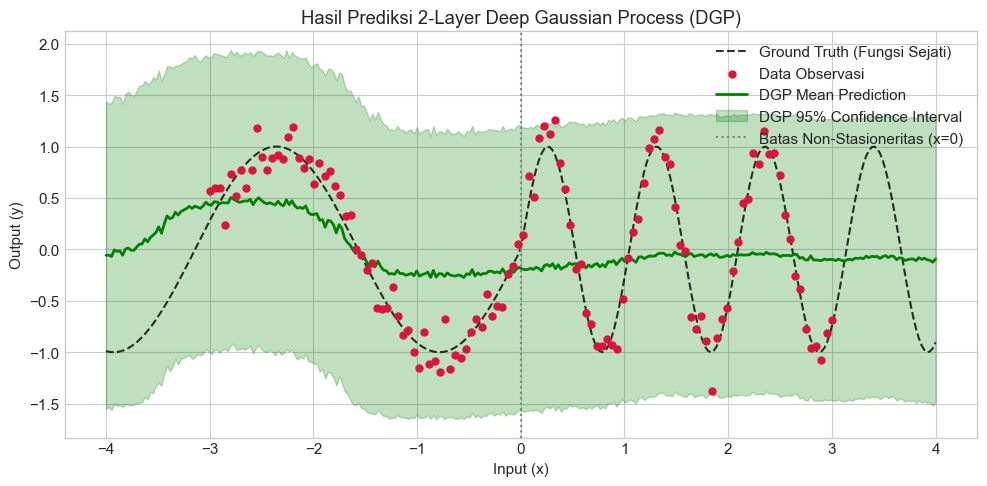

In [8]:
# Inference / Prediksi pada Test Grid X_test
num_test_samples = 100

with torch.no_grad():
    # Sampling 100 jalur fungsi Monte Carlo dari Deep GP
    f_samples_test, latents_test = dgp_model.forward(X_test, num_samples=num_test_samples, return_latents=True)
    # f_samples_test: (100, 300, 1)
    
    # Hitung Rata-rata (Mean) dan Standar Deviasi (Uncertainty) Prediksi
    dgp_mean = f_samples_test.mean(dim=0).squeeze().numpy()
    dgp_std_f = f_samples_test.std(dim=0).squeeze().numpy()
    # Total std termasuk noise observasi
    dgp_std_total = np.sqrt(dgp_std_f**2 + dgp_model.noise.item())

# Visualisasi Prediksi 2-Layer Deep GP
plt.figure(figsize=(10, 5))
plt.plot(X_test.numpy(), Y_test_true.numpy(), 'k--', label='Ground Truth (Fungsi Sejati)', alpha=0.8)
plt.scatter(X_train.numpy(), Y_train.numpy(), c='crimson', s=25, label='Data Observasi', zorder=4)

plt.plot(X_test.numpy(), dgp_mean, 'g-', linewidth=2, label='DGP Mean Prediction')
plt.fill_between(X_test.squeeze().numpy(), dgp_mean - 2*dgp_std_total, dgp_mean + 2*dgp_std_total, color='green', alpha=0.25, label='DGP 95% Confidence Interval')

plt.axvline(0, color='gray', linestyle=':', label='Batas Non-Stasioneritas (x=0)')
plt.title("Hasil Prediksi 2-Layer Deep Gaussian Process (DGP)")
plt.xlabel("Input (x)")
plt.ylabel("Output (y)")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Mengapa Deep GP Berhasil? Visualisasi *Input Space Warping* (Layer Tersembunyi)

Keunggulan utama Deep GP terletak pada kemampuan **Layer 1** untuk mempelajari fungsi pemetaan laten $h_1 = f^{(1)}(x)$:
- Pada area di mana fungsi target berubah sangat cepat ($x \ge 0$), Layer 1 **merekangkan** (*stretches*) nilai $h_1$.
- Pada area di mana fungsi target berubah lambat ($x < 0$), Layer 1 **mendorong/menekan** (*compresses*) nilai $h_1$.

Dengan demikian, ketika $h_1$ masuk ke **Layer 2**, fungsi tampak **stasioner bagi Kernel Layer 2**!

Mari kita visualisasikan representasi laten $h_1$ terhadap $x$.

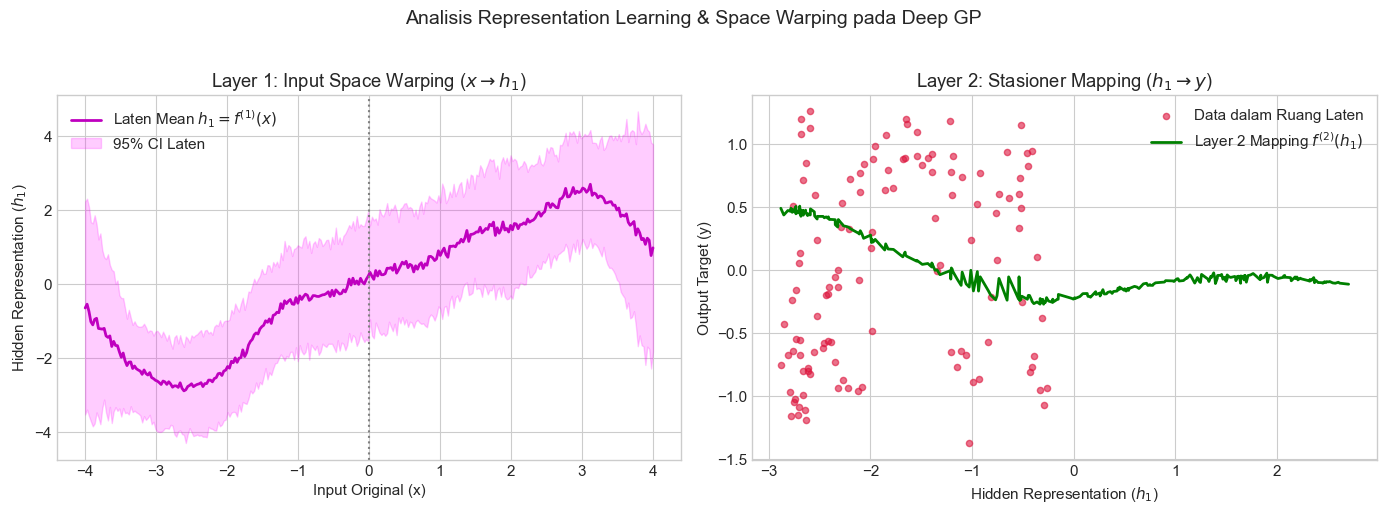

In [9]:
# Visualisasi Input Space Warping (x -> h_1)
with torch.no_grad():
    # Latent output Layer 1: latents_test[1] berukuran (S, N, 1)
    H1_samples = latents_test[1].squeeze(-1).numpy() # (S, N)
    H1_mean = H1_samples.mean(axis=0)
    H1_std = H1_samples.std(axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Warping Function x -> h_1
ax1.plot(X_test.numpy(), H1_mean, 'm-', linewidth=2, label=r'Laten Mean $h_1 = f^{(1)}(x)$')
ax1.fill_between(X_test.squeeze().numpy(), H1_mean - 2*H1_std, H1_mean + 2*H1_std, color='magenta', alpha=0.2, label='95% CI Laten')
ax1.axvline(0, color='gray', linestyle=':')
ax1.set_title(r"Layer 1: Input Space Warping ($x \rightarrow h_1$)")
ax1.set_xlabel("Input Original (x)")
ax1.set_ylabel(r"Hidden Representation ($h_1$)")
ax1.legend()
ax1.grid(True)

# Plot 2: Latent h_1 vs Output y
ax2.scatter(H1_mean[:len(X_train)], Y_train.numpy(), c='crimson', s=20, alpha=0.6, label='Data dalam Ruang Laten')
# Urutkan H1_mean untuk plotting curve
sort_idx = np.argsort(H1_mean)
ax2.plot(H1_mean[sort_idx], dgp_mean[sort_idx], 'g-', linewidth=2, label=r'Layer 2 Mapping $f^{(2)}(h_1)$')
ax2.set_title(r"Layer 2: Stasioner Mapping ($h_1 \rightarrow y$)")
ax2.set_xlabel(r"Hidden Representation ($h_1$)")
ax2.set_ylabel("Output Target (y)")
ax2.legend()
ax2.grid(True)

plt.suptitle("Analisis Representation Learning & Space Warping pada Deep GP", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Head-to-Head Comparison: Single GP vs Deep GP

Mari kita bandingkan secara berdampingan (*side-by-side*) performa **Single GP** dan **2-Layer Deep GP** pada dataset non-stasioner ini.

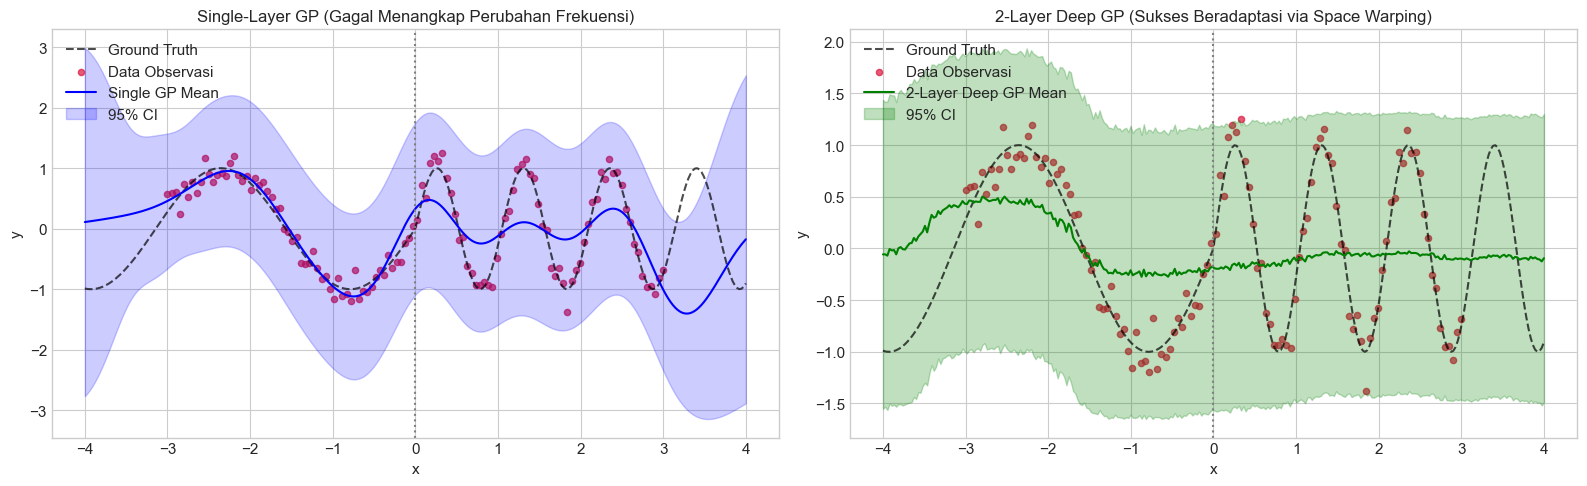

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Subplot 1: Single GP
axes[0].plot(X_test.numpy(), Y_test_true.numpy(), 'k--', label='Ground Truth', alpha=0.7)
axes[0].scatter(X_train.numpy(), Y_train.numpy(), c='crimson', s=20, alpha=0.7, label='Data Observasi')
axes[0].plot(X_test.numpy(), mu_sgp, 'b-', label='Single GP Mean')
axes[0].fill_between(X_test.squeeze().numpy(), mu_sgp - 2*std_sgp, mu_sgp + 2*std_sgp, color='blue', alpha=0.2, label='95% CI')
axes[0].axvline(0, color='gray', linestyle=':')
axes[0].set_title("Single-Layer GP (Gagal Menangkap Perubahan Frekuensi)", fontsize=12)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend(loc='upper left')

# Subplot 2: Deep GP
axes[1].plot(X_test.numpy(), Y_test_true.numpy(), 'k--', label='Ground Truth', alpha=0.7)
axes[1].scatter(X_train.numpy(), Y_train.numpy(), c='crimson', s=20, alpha=0.7, label='Data Observasi')
axes[1].plot(X_test.numpy(), dgp_mean, 'g-', label='2-Layer Deep GP Mean')
axes[1].fill_between(X_test.squeeze().numpy(), dgp_mean - 2*dgp_std_total, dgp_mean + 2*dgp_std_total, color='green', alpha=0.25, label='95% CI')
axes[1].axvline(0, color='gray', linestyle=':')
axes[1].set_title("2-Layer Deep GP (Sukses Beradaptasi via Space Warping)", fontsize=12)
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

## 8. Ringkasan & Kesimpulan

### 💡 Data Analysis & Modeling Key Findings:
1. **Keterbatasan Single-Layer GP**: GP standar dengan kernel RBF terikat pada nilai *lengthscale* konstan tunggal. Pada data non-stasioner, Single GP terpaksa mengambil kompromi yang menyebabkan *over-smoothing* di area frekuensi tinggi dan perkiraan ketidakpastian yang buruk.
2. **Kekuatan Deep GP (DGP)**: Dengan menumpuk beberapa layer GP secara hierarkis ($y = f^{(2)}(f^{(1)}(x))$), DGP mampu mempelajari **representasi laten non-linear (space warping)** pada layer pertama. Ini mengubah ruang input non-stasioner menjadi representasi laten yang mudah dipetakan oleh layer berikutnya.
3. **Inferensi Variasional Stochastic (DSVI)**: Karena pengintegralan variabel laten di layer tersembunyi *intractable*, kita menggunakan *Inducing Points* dan *Reparameterization Trick* untuk memperkirakan ikatan ELBO dan mengalirkan gradien Monte Carlo antar layer secara stabil.

---

### 🚀 Next Steps & Rekomendasi Eksperimen Lanjutan:
- **Pengaturan Arsitektur**: Cobalah menambah jumlah titik induksi ($M=32$) atau mencoba arsitektur lebih dalam (3-Layer DGP) untuk data multi-dimensi.
- **Multivariate Latent Space**: Pada masalah klasifikasi atau data berdimensi tinggi, dimensi laten $h_1$ bisa dibuat lebih besar dari 1 ($D_{latent} > 1$) untuk meningkatkan kapasitas representasi.